## 1. 데이터 준비

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_csv('./data/Yunu_data.csv')
df

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,Hepatitis_B,BMI,under_five_deaths,...,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Iso_code,Region,Region_encoded,Schooling,Measles
0,Afghanistan,2000,Developing,54.8,321.0,88,0.01,62.0,12.2,122,...,24.0,0.1,114.560000,2.3,2.5,AFG,Asia,1,1.264052,27.0
1,Afghanistan,2001,Developing,55.3,316.0,88,0.01,63.0,12.6,122,...,33.0,0.1,117.496980,2.1,2.4,AFG,Asia,1,1.315551,37.0
2,Afghanistan,2002,Developing,56.2,3.0,88,0.01,64.0,13.0,122,...,36.0,0.1,187.845950,19.9,2.2,AFG,Asia,1,1.367049,35.0
3,Afghanistan,2003,Developing,56.7,295.0,87,0.01,65.0,13.4,122,...,41.0,0.1,198.728544,19.7,19.9,AFG,Asia,1,1.418548,39.0
4,Afghanistan,2004,Developing,57.0,293.0,87,0.02,67.0,13.8,120,...,5.0,0.1,219.141353,19.5,19.7,AFG,Asia,1,1.470046,48.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2761,Zimbabwe,2011,Developing,54.9,464.0,28,6.00,94.0,29.9,42,...,93.0,13.3,839.927936,6.8,6.7,ZWE,Africa,0,7.768000,92.0
2762,Zimbabwe,2012,Developing,56.6,429.0,26,6.09,97.0,3.3,39,...,95.0,8.8,955.648466,6.5,6.4,ZWE,Africa,0,7.870000,97.0
2763,Zimbabwe,2013,Developing,58.0,399.0,25,6.39,95.0,3.8,36,...,95.0,6.8,111.227396,6.2,6.0,ZWE,Africa,0,7.990000,93.0
2764,Zimbabwe,2014,Developing,59.2,371.0,23,6.50,91.0,31.3,34,...,91.0,6.3,127.474620,5.9,5.7,ZWE,Africa,0,8.110000,92.0


In [2]:
encoded = [0 if status == 'Developing' else 1 for status in df['Status']]

df['Status'] = encoded
df.head()

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,Hepatitis_B,BMI,under_five_deaths,...,Diphtheria,HIV_AIDS,GDP,thinness _1_19_years,thinness_5_9_years,Iso_code,Region,Region_encoded,Schooling,Measles
0,Afghanistan,2000,0,54.8,321.0,88,0.01,62.0,12.2,122,...,24.0,0.1,114.560000,2.3,2.5,AFG,Asia,1,1.264052,27.0
1,Afghanistan,2001,0,55.3,316.0,88,0.01,63.0,12.6,122,...,33.0,0.1,117.496980,2.1,2.4,AFG,Asia,1,1.315551,37.0
2,Afghanistan,2002,0,56.2,3.0,88,0.01,64.0,13.0,122,...,36.0,0.1,187.845950,19.9,2.2,AFG,Asia,1,1.367049,35.0
3,Afghanistan,2003,0,56.7,295.0,87,0.01,65.0,13.4,122,...,41.0,0.1,198.728544,19.7,19.9,AFG,Asia,1,1.418548,39.0
4,Afghanistan,2004,0,57.0,293.0,87,0.02,67.0,13.8,120,...,5.0,0.1,219.141353,19.5,19.7,AFG,Asia,1,1.470046,48.0


In [3]:
df = df.drop(['infant_deaths', 'under_five_deaths'], axis=1)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2766 entries, 0 to 2765
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country               2766 non-null   object 
 1   Year                  2766 non-null   int64  
 2   Status                2766 non-null   int64  
 3   Life_expectancy       2766 non-null   float64
 4   Adult_Mortality       2766 non-null   float64
 5   Alcohol               2766 non-null   float64
 6   Hepatitis_B           2766 non-null   float64
 7   BMI                   2766 non-null   float64
 8   Polio                 2766 non-null   float64
 9   Diphtheria            2766 non-null   float64
 10  HIV_AIDS              2766 non-null   float64
 11  GDP                   2766 non-null   float64
 12  thinness _1_19_years  2766 non-null   float64
 13  thinness_5_9_years    2766 non-null   float64
 14  Iso_code              2766 non-null   object 
 15  Region               

## 2. 결측치 대체

### 2-1. 아프리카 제외한 다른 국가
- 아프리카를 제외한 다른 국가들은 전체적으로 분포가 비슷하여 크게 아프리카와 이외의 대륙으로 분리
- Hepatitis_B는 결측값이 너무 많아 예외로 봐야 함

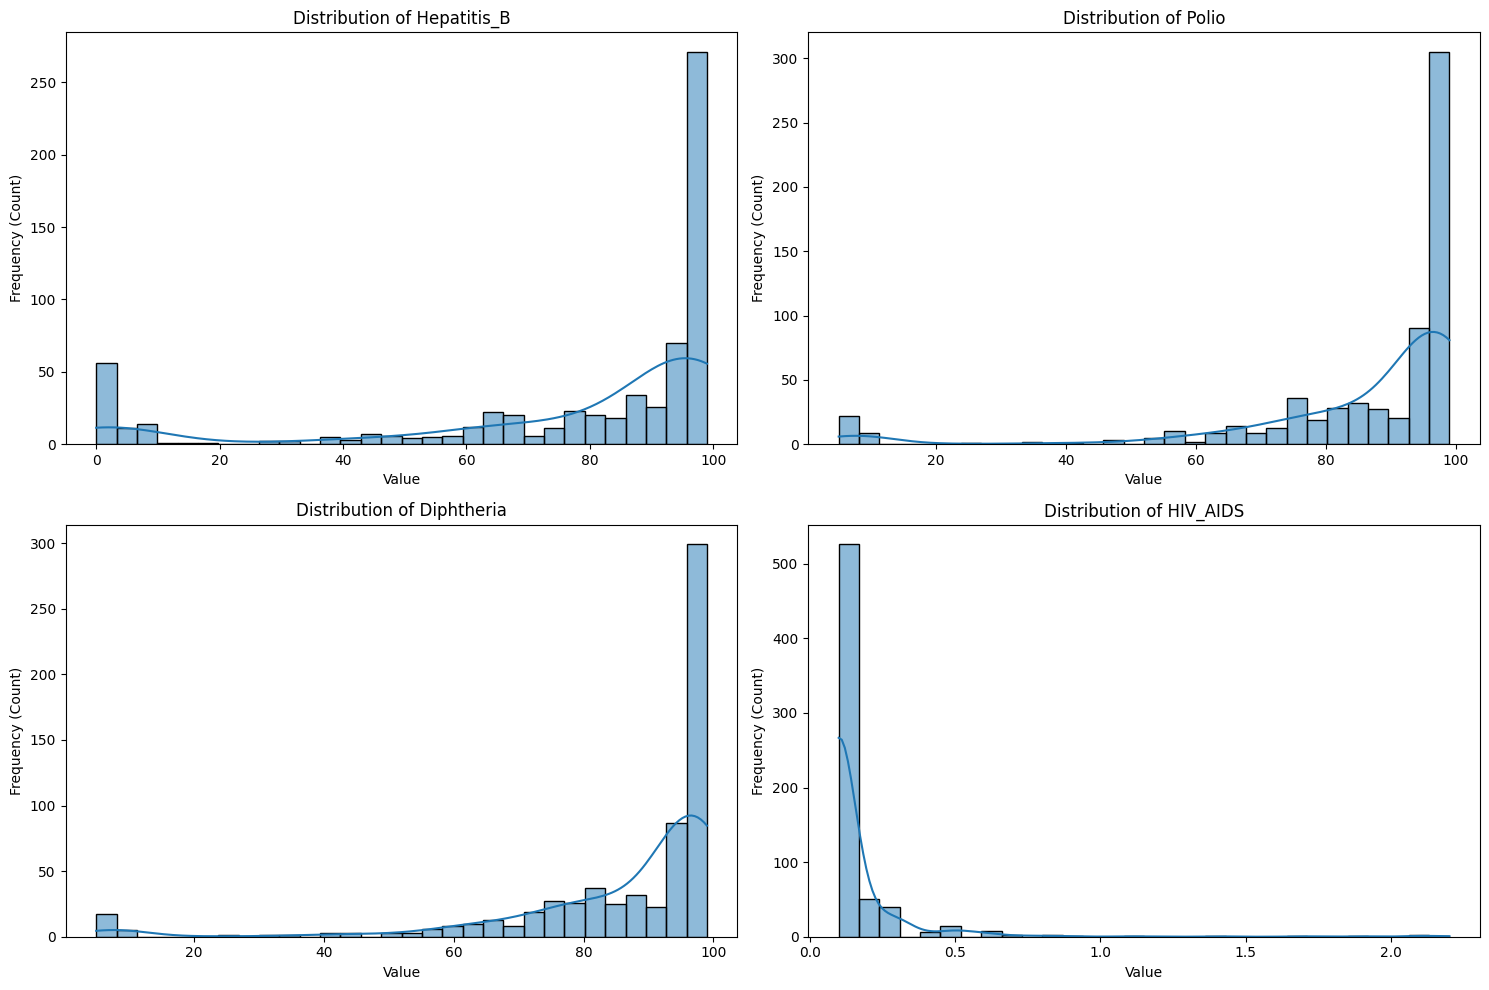

In [5]:
#1. 아시아
df_as = df[df['Region']=='Asia']
disease_as = df_as[['Hepatitis_B', 'Polio', 'Diphtheria', 'HIV_AIDS']]
plt.figure(figsize=(15, 10))
for i, col in enumerate(disease_as.columns):
    plt.subplot(2, 2, i+1)
    sns.histplot(disease_as[col], kde=True, bins=30) # kde=True는 부드러운 곡선을 추가해줍니다.
    plt.title(f'Distribution of {col}')
    plt.xlabel('Value')
    plt.ylabel('Frequency (Count)')

plt.tight_layout()
plt.show()

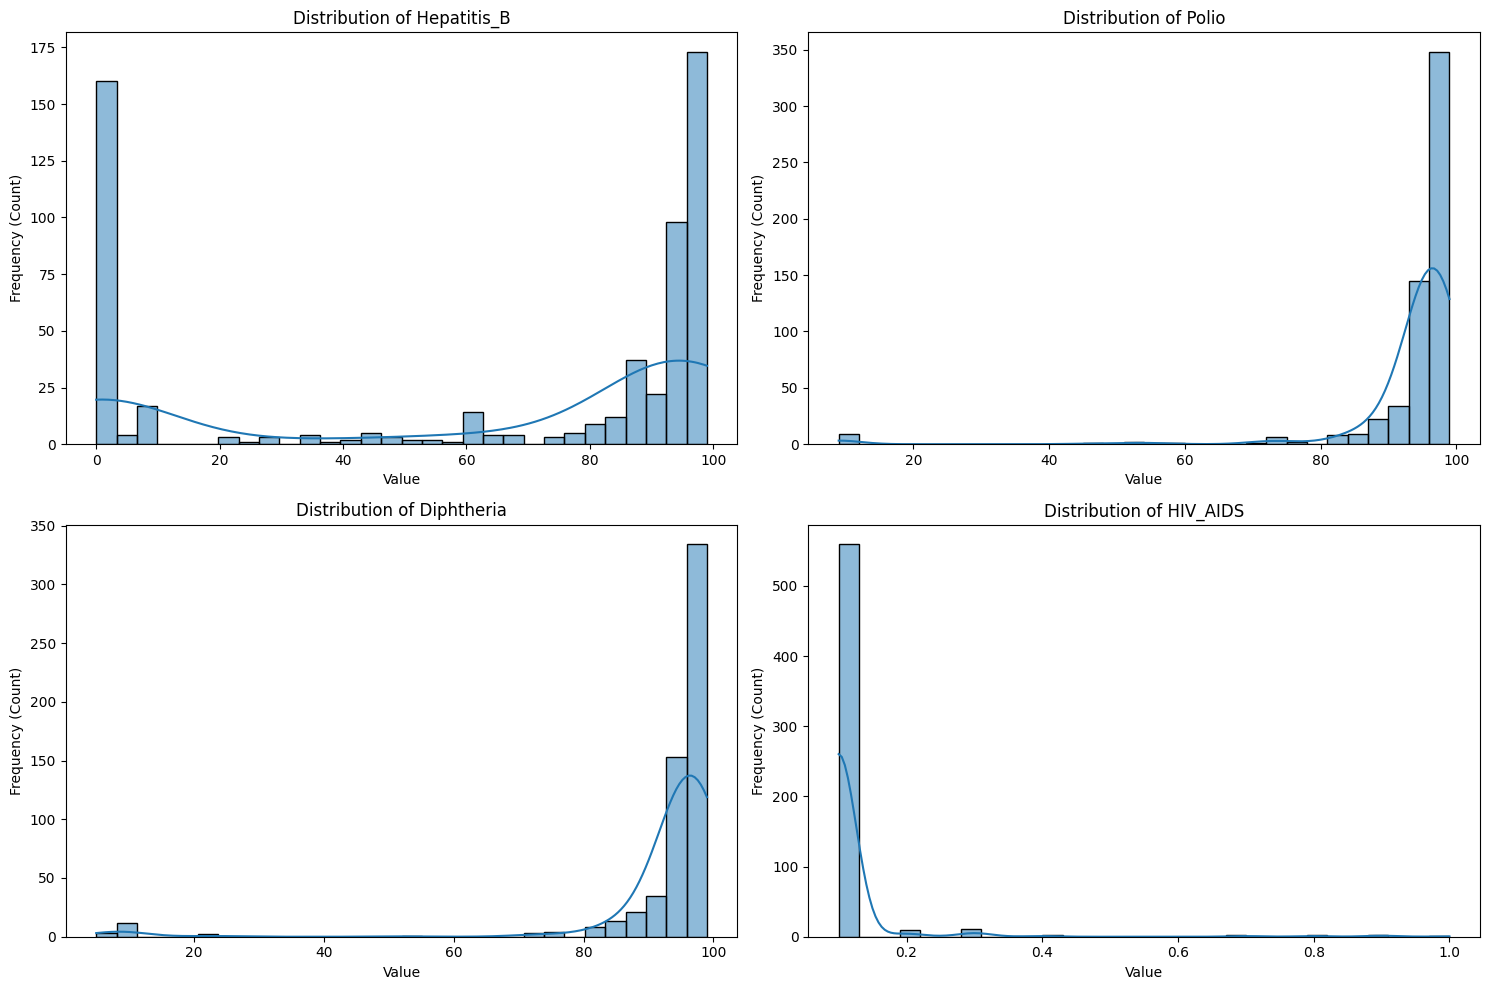

In [6]:
#2. 유럽
df_eu = df[df['Region']=='Europe']
disease_eu = df_eu[['Hepatitis_B', 'Polio', 'Diphtheria', 'HIV_AIDS']]
plt.figure(figsize=(15, 10))
for i, col in enumerate(disease_eu.columns):
    plt.subplot(2, 2, i+1)
    sns.histplot(disease_eu[col], kde=True, bins=30) # kde=True는 부드러운 곡선을 추가해줍니다.
    plt.title(f'Distribution of {col}')
    plt.xlabel('Value')
    plt.ylabel('Frequency (Count)')

plt.tight_layout()
plt.show()

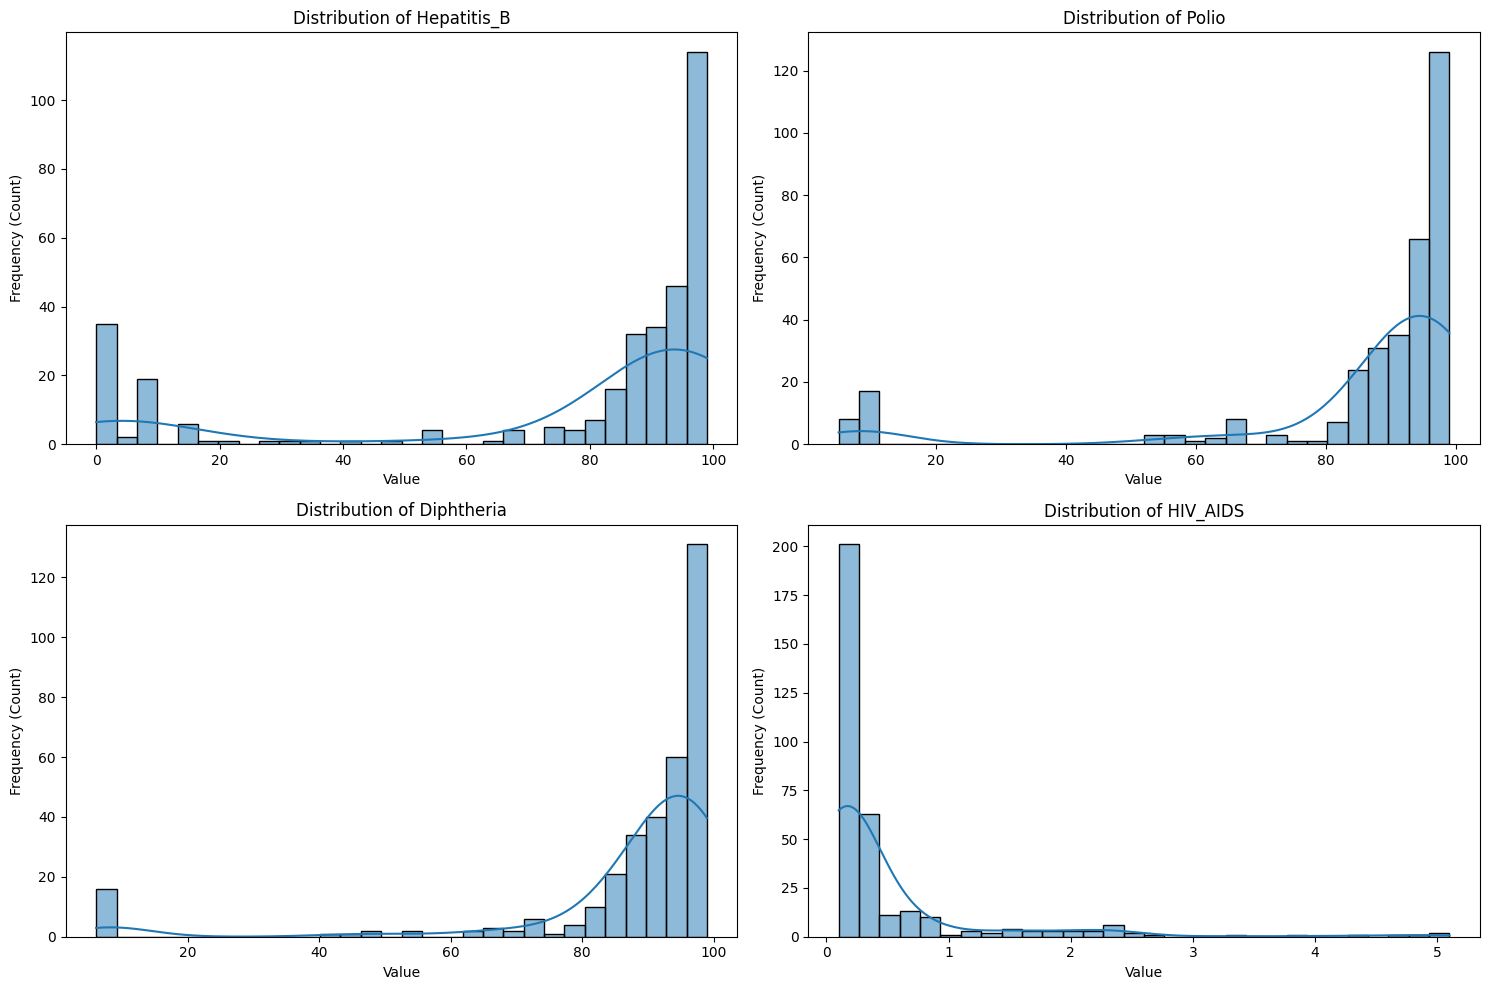

In [7]:
#2. 북아메리카
df_nam = df[df['Region']=='North America']
disease_nam = df_nam[['Hepatitis_B', 'Polio', 'Diphtheria', 'HIV_AIDS']]
plt.figure(figsize=(15, 10))
for i, col in enumerate(disease_nam.columns):
    plt.subplot(2, 2, i+1)
    sns.histplot(disease_nam[col], kde=True, bins=30) # kde=True는 부드러운 곡선을 추가해줍니다.
    plt.title(f'Distribution of {col}')
    plt.xlabel('Value')
    plt.ylabel('Frequency (Count)')

plt.tight_layout()
plt.show()

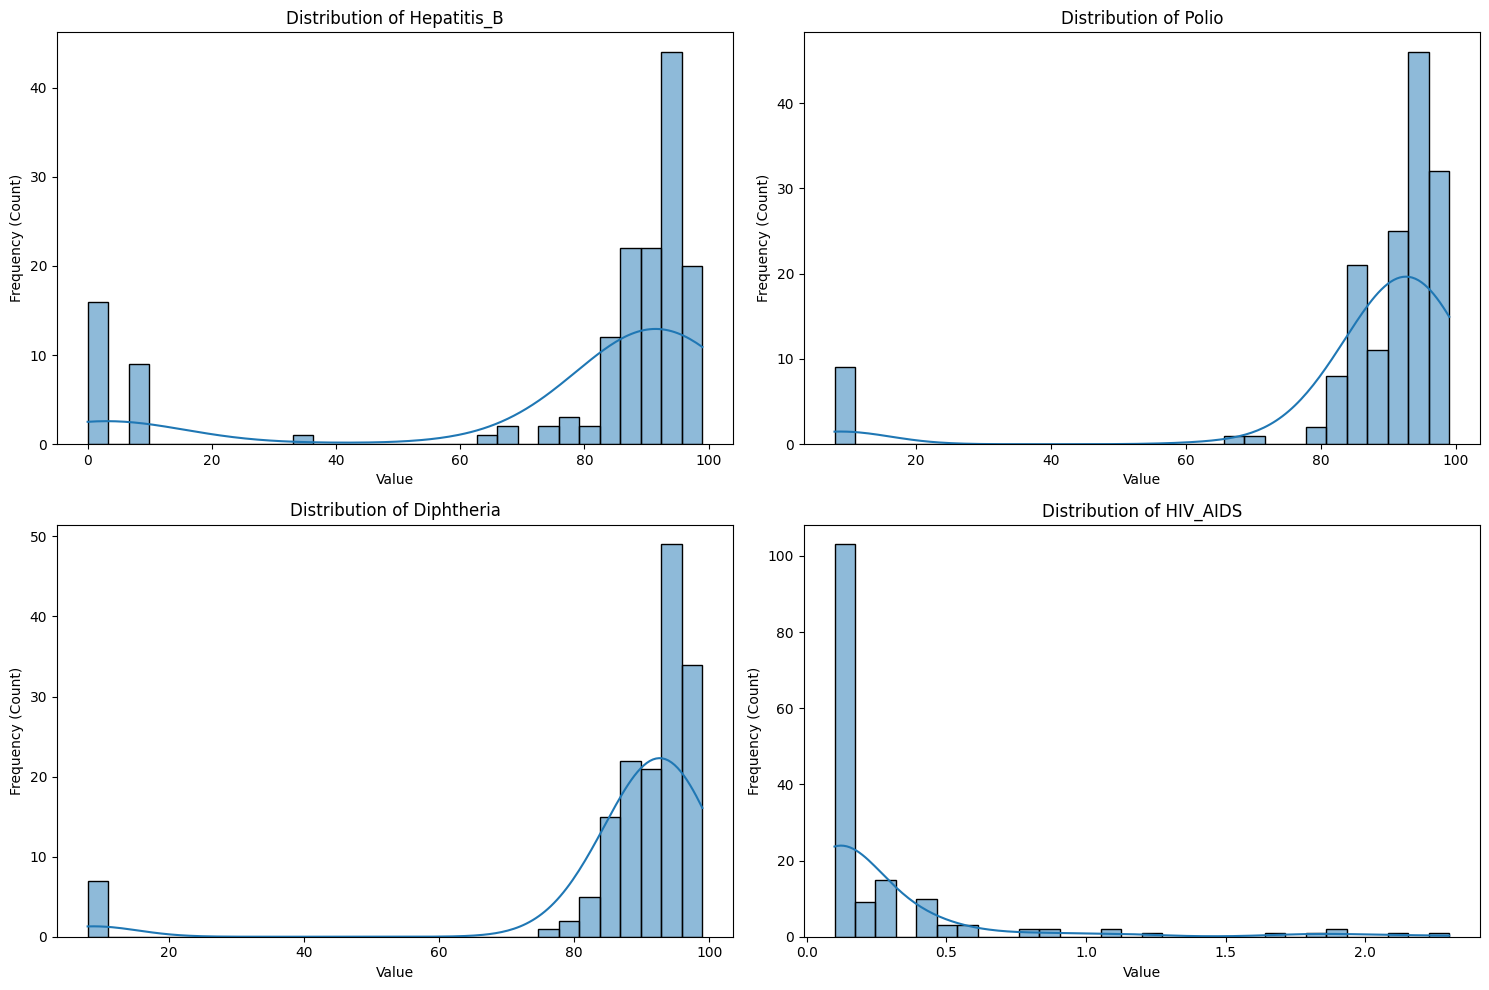

In [8]:
#2. 남아메리카
df_sam = df[df['Region']=='South America']
disease_sam = df_sam[['Hepatitis_B', 'Polio', 'Diphtheria', 'HIV_AIDS']]
plt.figure(figsize=(15, 10))
for i, col in enumerate(disease_sam.columns):
    plt.subplot(2, 2, i+1)
    sns.histplot(disease_sam[col], kde=True, bins=30) # kde=True는 부드러운 곡선을 추가해줍니다.
    plt.title(f'Distribution of {col}')
    plt.xlabel('Value')
    plt.ylabel('Frequency (Count)')

plt.tight_layout()
plt.show()

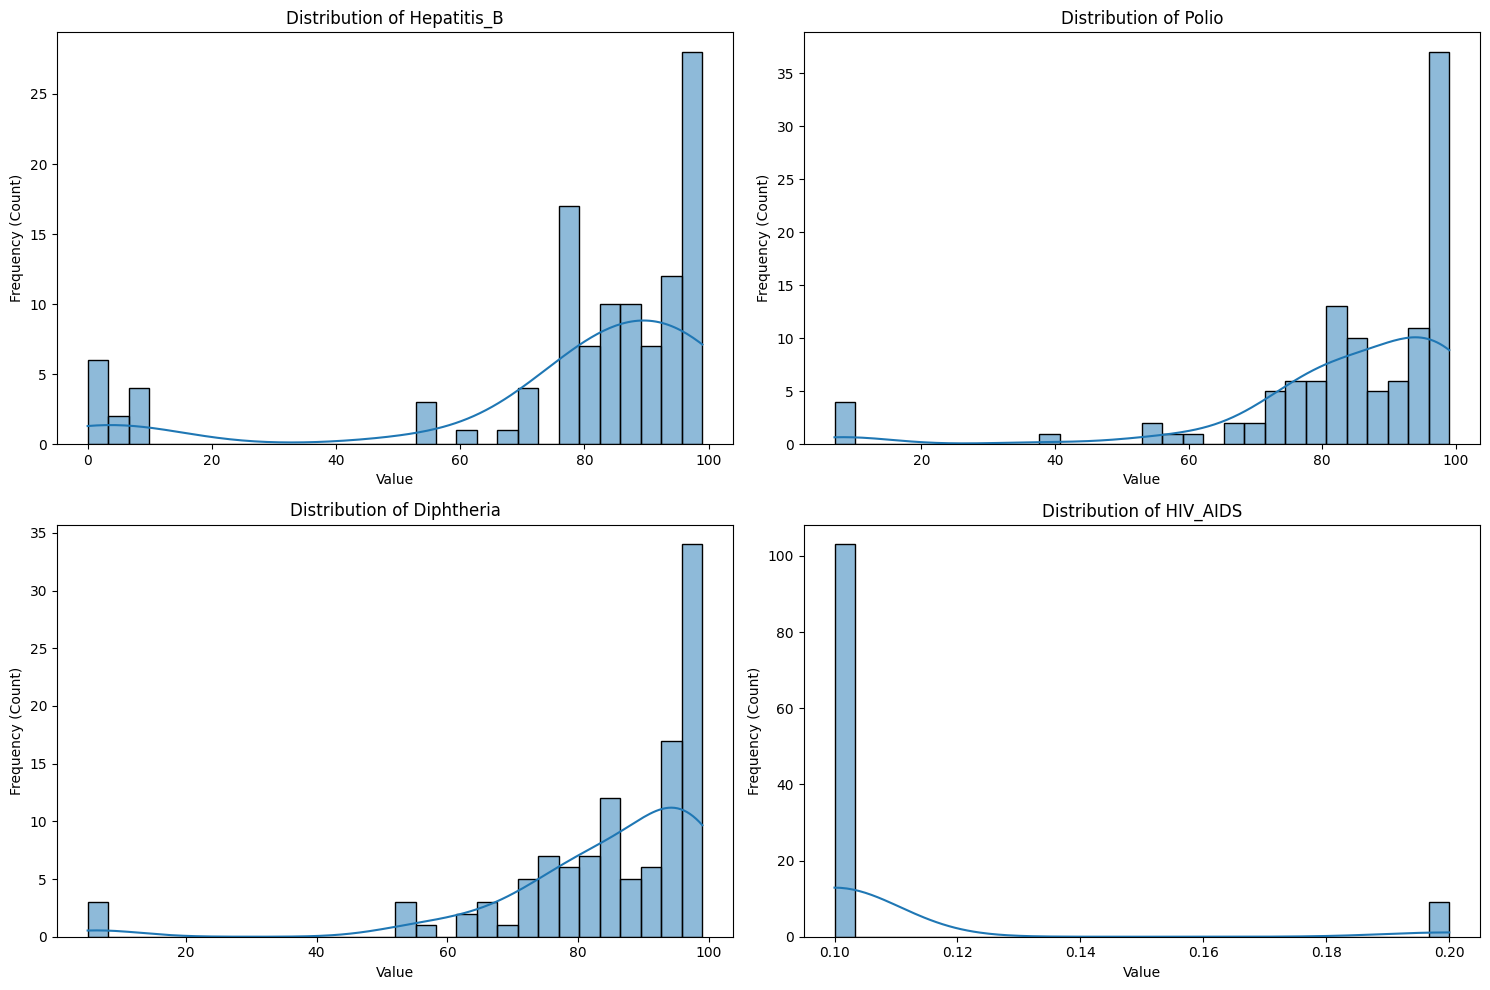

In [9]:
#나머지 대륙
df_others = df[df['Region']=='Others']
disease_others = df_others[['Hepatitis_B', 'Polio', 'Diphtheria', 'HIV_AIDS']]
plt.figure(figsize=(15, 10))
for i, col in enumerate(disease_others.columns):
    plt.subplot(2, 2, i+1)
    sns.histplot(df_others[col], kde=True, bins=30) # kde=True는 부드러운 곡선을 추가해줍니다.
    plt.title(f'Distribution of {col}')
    plt.xlabel('Value')
    plt.ylabel('Frequency (Count)')

plt.tight_layout()
plt.show()

### 2-2. 아프리카 + 이상치 처리

In [10]:
df_af = df[df['Region']=='Africa']

In [11]:
disease_af = df_af[['Hepatitis_B', 'Polio', 'Diphtheria', 'HIV_AIDS']]
disease_af.describe()

,Hepatitis_B,Polio,Diphtheria,HIV_AIDS
count,774.000000,774.000000,774.000000,774.000000
mean,56.845690,71.383721,70.620155,5.204005
std,39.665314,26.702545,28.090234,7.279891
min,0.000000,3.000000,2.000000,0.100000
25%,6.250000,59.000000,59.000000,0.800000
50%,75.000000,78.000000,79.000000,2.500000
75%,92.000000,93.000000,93.000000,6.000000
max,99.000000,99.000000,99.000000,43.500000


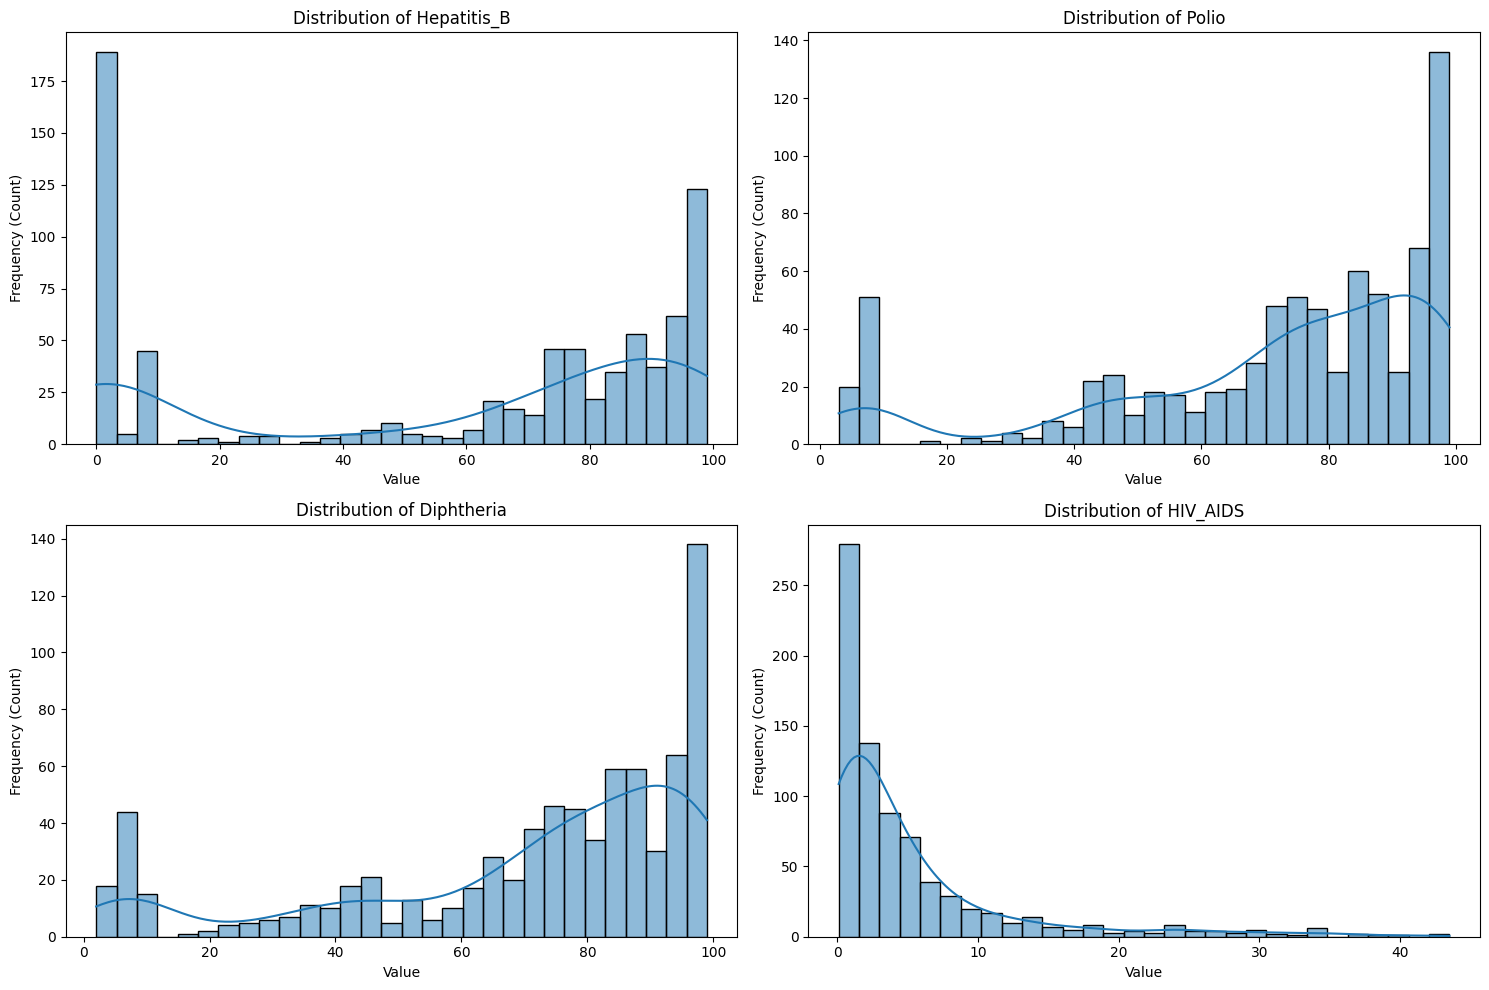

In [12]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(disease_af.columns):
    plt.subplot(2, 2, i+1)
    sns.histplot(disease_af[col], kde=True, bins=30) # kde=True는 부드러운 곡선을 추가해줍니다.
    plt.title(f'Distribution of {col}')
    plt.xlabel('Value')
    plt.ylabel('Frequency (Count)')

plt.tight_layout()
plt.show()

In [13]:
import pandas as pd
import numpy as np

# 1. Adult_Mortality 삭제
if 'Adult_Mortality' in df.columns:
    df.drop(columns=['Adult_Mortality'], inplace=True)

v_cols = ['Hepatitis_B', 'Polio', 'Diphtheria', 'Measles']

# 2. 이상치 제거 (원본 df에 NaN 즉시 대입)
for col in v_cols:
    # [비-아프리카] 20 미만
    df.loc[(df['Region'] != 'Africa') & (df[col] < 20), col] = np.nan
    # [아프리카] 15 미만 (과도한 보정 방지를 위해 15로 조정)
    df.loc[(df['Region'] == 'Africa') & (df[col] < 15), col] = np.nan
    
    # [논리적 불일치] Polio와 40 이상 차이 나면 해당 컬럼 NaN 처리
    if col != 'Polio':
        diff = (df[col] - df['Polio']).abs()
        df.loc[diff > 40, col] = np.nan

# 4. 원본 df의 결측치를 대륙별 중앙값으로 덮어쓰기
for col in v_cols:
    # transform은 원본과 index가 같은 Series를 반환함
    fill_values = df.groupby('Region')[col].transform('median')
    # fillna 결과를 다시 df[col]에 할당하여 원본 수정
    df[col] = df[col].fillna(fill_values)

# 결과 확인
print("✅ 원본 df 수정 완료")
print(df[v_cols].min())

✅ 원본 df 수정 완료
Hepatitis_B    16.0
Polio          17.0
Diphtheria     16.0
Measles        16.0
dtype: float64


In [14]:
df.to_csv('cleaned_disease_data.csv', index=False, encoding='utf-8-sig')